# Huấn luyện mô hình — XGBoost (DKA-AKI)

## Mục tiêu
Bài báo *fpubh-11-1087297* so sánh 8 mô hình ML và kết luận **XGBoost (eXtreme Gradient Boosting) là mô hình tốt nhất**: AUC trên tập **train = 0.835**, **validation = 0.800**; top 5 đặc trưng quan trọng là **BUN, urine output, weight, age, PLT**. Notebook này tái hiện XGBoost theo đúng quy trình của `modeling_randomforest.ipynb` để **so sánh trực tiếp** với Random Forest:
1. Đọc `train_processed.csv`, tách `X`, `y`, chia train/validation **theo phân tầng (stratify)**.
2. Huấn luyện **XGBoost** (bù mất cân bằng bằng `scale_pos_weight`).
3. Đánh giá trên validation bằng các độ đo của bài báo (AUC, accuracy, sensitivity, specificity, F1).
4. Áp dụng **cùng** `flatten` + `preprocessor.joblib` (chỉ `transform`) cho `test.json`.
5. Dự đoán tập test và ghi kết quả ra thư mục `output/`.

> Yêu cầu: đã chạy `preprocessing.ipynb` để sinh ra `data/train_processed.csv` và `data/preprocessor.joblib`.
>
> **Phụ thuộc:** notebook này cần gói `xgboost` (đã thêm vào `requirements.txt`); nếu chạy trong Docker thì **build lại image** trước khi mở.
>
> *Lưu ý về cách chia dữ liệu:* bài báo dùng 85/15 + 10-fold CV để tinh chỉnh siêu tham số; ở đây giữ **80/20 stratify giống `modeling_randomforest.ipynb`** để hai mô hình so sánh được trên cùng một tập validation.

## 1. Thư viện sử dụng

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             confusion_matrix, classification_report, roc_curve)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
%matplotlib inline

## 2. Đọc dữ liệu đã xử lý

`train_processed.csv` do bước tiền xử lý sinh ra: các đặc trưng đã làm sạch/chuẩn hoá + cột nhãn `akdPositive`.

In [2]:
DATA_DIR = os.path.join('..', 'data')
OUTPUT_DIR = os.path.join('..', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = 'akdPositive'
data = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'))
X = data.drop(columns=[TARGET])
y = data[TARGET]
print('Kích thước X:', X.shape, '| số đặc trưng:', X.shape[1])
print('Phân bố nhãn:', dict(y.value_counts()))
print('Tỉ lệ dương tính: {:.1%}'.format(y.mean()))

Kích thước X: (970, 77) | số đặc trưng: 77
Phân bố nhãn: {0: 593, 1: 377}
Tỉ lệ dương tính: 38.9%


**Nhận xét:** **970 bệnh nhân × 77 đặc trưng**, tỉ lệ dương tính ≈ **38.9%** (mất cân bằng nhẹ). Vì vậy ta sẽ (1) chia dữ liệu **stratify** và (2) dùng `scale_pos_weight = n_âm / n_dương` cho XGBoost (tương đương `class_weight='balanced'` của Random Forest).

## 3. Chia train / validation (phân tầng)

Vì tập `test.json` **không có nhãn**, ta tách 20% dữ liệu train làm **validation** để đánh giá mô hình. `stratify=y` giữ nguyên tỉ lệ 39% ở cả hai phần.

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_tr.shape, '| Validation:', X_val.shape)
print('Tỉ lệ dương tính — train: {:.1%}, val: {:.1%}'.format(y_tr.mean(), y_val.mean()))

Train: (776, 77) | Validation: (194, 77)
Tỉ lệ dương tính — train: 38.9%, val: 38.7%


**Nhận xét:** ~776 mẫu train / ~194 mẫu validation, tỉ lệ dương tính giữ nguyên ở cả hai (nhờ `stratify`).

## 4. Huấn luyện XGBoost

XGBoost xây dựng **tuần tự** nhiều cây quyết định, cây sau sửa lỗi của các cây trước (gradient boosting). Tham số chính:
- `n_estimators=400`, `learning_rate=0.05`: nhiều cây + bước học nhỏ ⇒ học từ từ, ít overfit.
- `max_depth=4`, `min_child_weight=2`: giới hạn độ sâu/độ phức tạp mỗi cây.
- `subsample=0.9`, `colsample_bytree=0.9`: lấy mẫu ngẫu nhiên hàng/cột mỗi cây ⇒ giảm overfit.
- `reg_lambda=1.0`: điều chuẩn L2.
- `scale_pos_weight = n_âm / n_dương`: bù cho nhãn mất cân bằng.
- `eval_metric='auc'`, `random_state` cố định để tái lập kết quả.

In [4]:
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print('scale_pos_weight (n_âm / n_dương) = {:.3f}'.format(spw))

xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0, gamma=0.0,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw, n_jobs=-1, random_state=RANDOM_STATE)
xgb.fit(X_tr, y_tr)
print('Đã huấn luyện xong XGBoost với', xgb.n_estimators, 'cây.')

scale_pos_weight (n_âm / n_dương) = 1.570
Đã huấn luyện xong XGBoost với 400 cây.


**Nhận xét:** mô hình đã học xong trên tập train. Tiếp theo đánh giá khả năng tổng quát hoá trên validation.

## 5. Đánh giá trên tập validation

Dùng đúng các độ đo của bài báo:
- **AUC**: khả năng phân biệt 2 lớp (càng gần 1 càng tốt).
- **Sensitivity** (độ nhạy/recall lớp dương): tỉ lệ bắt đúng ca AKI — rất quan trọng trên lâm sàng.
- **Specificity** (độ đặc hiệu): tỉ lệ nhận đúng ca không AKI.
- **Accuracy**, **F1**.

In [5]:
proba_val = xgb.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.5).astype(int)

auc = roc_auc_score(y_val, proba_val)
acc = accuracy_score(y_val, pred_val)
f1 = f1_score(y_val, pred_val)
tn, fp, fn, tp = confusion_matrix(y_val, pred_val).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print('AUC        : {:.3f}'.format(auc))
print('Accuracy   : {:.3f}'.format(acc))
print('Sensitivity: {:.3f}'.format(sensitivity))
print('Specificity: {:.3f}'.format(specificity))
print('F1         : {:.3f}'.format(f1))
print('\nConfusion matrix [[TN, FP], [FN, TP]]:')
print(confusion_matrix(y_val, pred_val))
print('\n', classification_report(y_val, pred_val, target_names=['no-AKI', 'AKI']))

AUC        : 0.817
Accuracy   : 0.758
Sensitivity: 0.720
Specificity: 0.782
F1         : 0.697

Confusion matrix [[TN, FP], [FN, TP]]:
[[93 26]
 [21 54]]

               precision    recall  f1-score   support

      no-AKI       0.82      0.78      0.80       119
         AKI       0.68      0.72      0.70        75

    accuracy                           0.76       194
   macro avg       0.75      0.75      0.75       194
weighted avg       0.76      0.76      0.76       194



**Cách đọc kết quả:** bài báo đạt **AUC = 0.800** trên validation với XGBoost — đây là mốc tham chiếu. Nếu **sensitivity thấp** (bỏ sót ca AKI), có thể **hạ ngưỡng** dự đoán xuống dưới 0.5 hoặc tăng `scale_pos_weight`. Ma trận nhầm lẫn cho biết mô hình sai ở đâu (FP vs FN).

### 5.1 So sánh Train vs Validation (kiểm tra overfitting)

Cùng các độ đo trên nhưng tính cho **cả tập train lẫn validation**. Chênh lệch lớn giữa hai cột ⇒ mô hình **overfit** (học thuộc dữ liệu train, kém tổng quát hoá).

In [6]:
def compute_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'AUC': roc_auc_score(y, proba),
        'Accuracy': accuracy_score(y, pred),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'F1': f1_score(y, pred),
    }

compare = pd.DataFrame({
    'Train': compute_metrics(xgb, X_tr, y_tr),
    'Validation': compute_metrics(xgb, X_val, y_val),
}).round(3)
print('Hiệu năng XGBoost — Train vs Validation:')
print(compare)

Hiệu năng XGBoost — Train vs Validation:
             Train  Validation
AUC            1.0       0.817
Accuracy       1.0       0.758
Sensitivity    1.0       0.720
Specificity    1.0       0.782
F1             1.0       0.697


**Nhận xét:** trên dữ liệu nhỏ này XGBoost vẫn đạt **train AUC ≈ 1.0** (400 cây đủ để học thuộc 776 mẫu) — tương tự Random Forest. Điều đáng giá là **trên validation XGBoost nhỉnh hơn RF**: AUC **0.817** (RF 0.806) và **sensitivity 0.72** (RF 0.67) — ít bỏ sót ca AKI hơn, khớp với kết luận của bài báo rằng XGBoost là mô hình tốt nhất (val AUC 0.800). Khoảng cách train − validation vẫn lớn ⇒ có thể giảm `n_estimators`/`max_depth`, tăng `reg_lambda`/`min_child_weight`, hoặc dùng early stopping để chống overfit.

### 5.2 Đường cong ROC

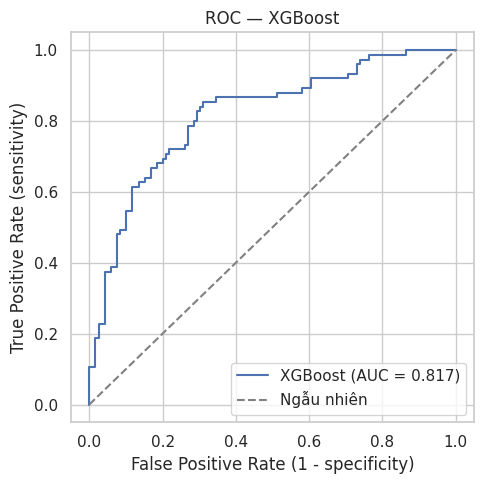

In [7]:
fpr, tpr, _ = roc_curve(y_val, proba_val)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.3f})'.format(auc))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Ngẫu nhiên')
plt.xlabel('False Positive Rate (1 - specificity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC — XGBoost'); plt.legend(); plt.tight_layout()
plt.show()

**Nhận xét:** đường ROC càng cong lên góc trái trên càng tốt; diện tích dưới đường = AUC ở trên.

## 6. Độ quan trọng của đặc trưng

XGBoost cho biết đặc trưng nào đóng góp nhiều nhất vào dự đoán. Ta đối chiếu với bài báo (top 5: **BUN, urine output, weight, age, PLT**; ở dữ liệu này không có urine output).

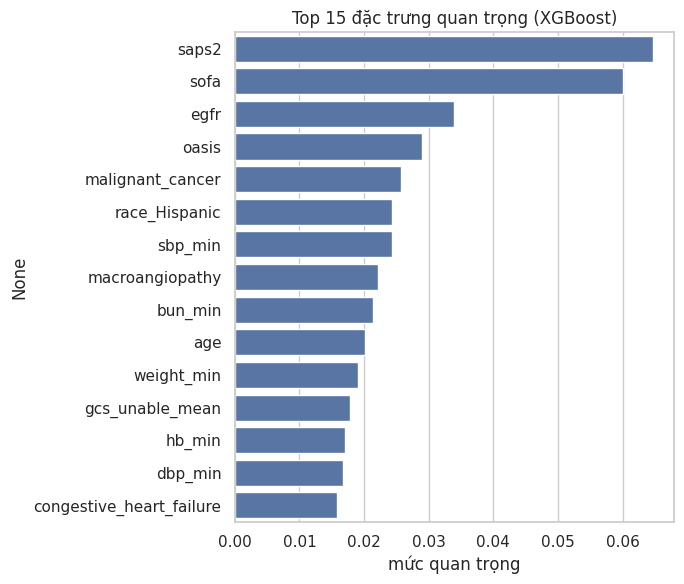

saps2                       0.0647
sofa                        0.0601
egfr                        0.0340
oasis                       0.0289
malignant_cancer            0.0256
race_Hispanic               0.0244
sbp_min                     0.0243
macroangiopathy             0.0222
bun_min                     0.0214
age                         0.0202
weight_min                  0.0190
gcs_unable_mean             0.0178
hb_min                      0.0170
dbp_min                     0.0168
congestive_heart_failure    0.0159
dtype: float32

In [8]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
top = importances.head(15)
plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index)
plt.title('Top 15 đặc trưng quan trọng (XGBoost)'); plt.xlabel('mức quan trọng')
plt.tight_layout(); plt.show()
top.round(4)

**Nhận xét:** kỳ vọng các đặc trưng liên quan đến **BUN, tuổi, cân nặng, độ nặng (SAPS2/OASIS/SOFA), eGFR, PLT** nằm ở nhóm đầu — trùng hướng với top 5 của bài báo (trừ urine output không có trong dữ liệu) và với phân tích tương quan ở notebook tiền xử lý.

## 7. Huấn luyện lại trên toàn bộ dữ liệu train (mô hình cuối)

Sau khi đã đánh giá, ta huấn luyện lại trên **toàn bộ 970 mẫu** để mô hình cuối tận dụng tối đa dữ liệu trước khi dự đoán tập test (validation chỉ dùng để ước lượng hiệu năng).

In [9]:
spw_full = (y == 0).sum() / (y == 1).sum()
xgb_final = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
    reg_lambda=1.0, gamma=0.0,
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=spw_full, n_jobs=-1, random_state=RANDOM_STATE)
xgb_final.fit(X, y)
print('Đã huấn luyện mô hình cuối trên', X.shape[0], 'mẫu.')

Đã huấn luyện mô hình cuối trên 970 mẫu.


**Nhận xét:** `xgb_final` là mô hình sẽ dùng để dự đoán tập test.

## 8. Tiền xử lý `test.json` bằng đúng quy trình của train

Đây là bước **dễ sai** nhất: tập test phải được biến đổi **y hệt** tập train, và **chỉ `transform`** (không `fit`) bằng bộ `preprocessor.joblib` đã lưu — nếu fit lại trên test sẽ gây **rò rỉ dữ liệu**.

Quy trình: `flatten` (min/mean/max) → bỏ cột đã loại → `imputer.transform` → mã hoá phân loại → `scaler.transform` → **căn cột về đúng `feature_cols`** của train (cột one-hot thiếu điền 0).

In [10]:
art = joblib.load(os.path.join(DATA_DIR, 'preprocessor.joblib'))
imputer = art['imputer']
scaler = art['scaler']
numeric_cols = art['numeric_cols']
feature_cols = art['feature_cols']
dropped_cols = art['dropped_cols']
TS_KEYS = art['ts_keys']
STATS = art['stats']

# Các nhóm khác (giống hệt preprocessing.ipynb)
NUM_SCALAR = ['age', 'oasis', 'saps2', 'sofa', 'preiculos', 'egfr']
ALWAYS_BOOL = ['chronic_pulmonary_disease', 'congestive_heart_failure', 'malignant_cancer']
COMORBID_FLAGS = ['hypertension', 'microangiopathy', 'macroangiopathy',
                  'history_ami', 'uti', 'history_aci']
CKD = 'ckd_stage'
ID_COLS = ['subjectId', 'hadmId', 'stayId']

def agg_series(ts):
    a = np.array(list(ts.values()), dtype=float)
    return np.nanmin(a), np.nanmean(a), np.nanmax(a)

def flatten(record):
    m = record['measures']
    row = {'subjectId': record['subjectId'], 'hadmId': record['hadmId'], 'stayId': record['stayId']}
    for k in TS_KEYS:
        v = m.get(k)
        vals = agg_series(v) if isinstance(v, dict) and len(v) > 0 else (np.nan, np.nan, np.nan)
        for s, val in zip(STATS, vals):
            row[f'{k}_{s}'] = val
    for k in NUM_SCALAR + ['gender', 'race', 'liver_disease', 'dka_type']:
        row[k] = m.get(k, np.nan)
    for k in ALWAYS_BOOL + COMORBID_FLAGS:
        row[k] = int(bool(m.get(k, False)))
    row[CKD] = m.get(CKD, 0)
    return row

def group_race(s):
    s = str(s).upper()
    if 'WHITE' in s:
        return 'White'
    if 'BLACK' in s or 'AFRICAN' in s:
        return 'Black'
    if 'HISPANIC' in s or 'LATINO' in s:
        return 'Hispanic'
    if 'ASIAN' in s:
        return 'Asian'
    return 'Other'

def preprocess_records(records):
    """Biến đổi danh sách bản ghi -> (bảng id, ma trận đặc trưng X) khớp với train."""
    df = pd.DataFrame([flatten(r) for r in records])
    ids = df[ID_COLS].copy()
    df = df.drop(columns=dropped_cols, errors='ignore')
    # 1) điền thiếu bằng imputer đã fit trên train (chỉ transform)
    df[numeric_cols] = imputer.transform(df[numeric_cols])
    # 2) mã hoá phân loại y hệt train
    df['gender'] = df['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    df['liver_disease'] = df['liver_disease'].map({'NONE': 0, 'MILD': 1, 'SEVERE': 2}).fillna(0).astype(int)
    df['race_group'] = df['race'].apply(group_race)
    df = df.drop(columns=['race'])
    df['dka_type'] = df['dka_type'].map({1: 'T1DM', 2: 'T2DM', 0: 'Other'}).fillna('Other')
    df = pd.get_dummies(df, columns=['race_group', 'dka_type'], prefix=['race', 'dka'])
    df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
    # 3) chuẩn hoá bằng scaler đã fit trên train
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    # 4) căn cột về đúng feature_cols (one-hot thiếu -> 0, đúng thứ tự)
    X_out = df.reindex(columns=feature_cols, fill_value=0)
    return ids, X_out

In [11]:
with open(os.path.join(DATA_DIR, 'test.json'), encoding='utf-8') as f:
    test = json.load(f)

ids_test, X_test = preprocess_records(test)
print('Số bản ghi test:', len(test))
print('Kích thước X_test:', X_test.shape)
print('Khớp đúng cột train?', list(X_test.columns) == list(feature_cols))
print('Còn giá trị thiếu?', bool(X_test.isnull().any().any()))

Số bản ghi test: 243
Kích thước X_test: (243, 77)
Khớp đúng cột train? True
Còn giá trị thiếu? False


**Nhận xét:** `X_test` có **243 × 77**, cột **khớp đúng** thứ tự `feature_cols` của train và **không còn thiếu** — sẵn sàng đưa vào mô hình. (Đã kiểm tra trước: train & test sinh cùng 77 cột, không có nhãn phân loại lạ.)

## 9. Dự đoán tập test & lưu kết quả ra `output/`

File CSV kết quả chỉ gồm **đúng 3 cột**: `id` (= `subjectId`), `probability` (xác suất AKI), `prediction` (nhãn 0/1 ở ngưỡng 0.5).

> **Lưu ý:** một bệnh nhân (`subjectId`) có thể xuất hiện ở **nhiều bản ghi** (khác `hadmId`/`stayId`). Theo yêu cầu, **mỗi `id` chỉ lưu kết quả của một bản ghi** — giữ bản ghi **đầu tiên** xuất hiện trong tập test.

In [ ]:
proba_test = xgb_final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

# File kết quả chỉ gồm 3 cột: id (= subjectId), probability, prediction
result = pd.DataFrame({
    'id': ids_test['subjectId'].values,
    'probability': np.round(proba_test, 4),
    'prediction': pred_test,
})

# Một bệnh nhân (id = subjectId) có thể có nhiều lần nằm ICU; mỗi id chỉ giữ MỘT bản ghi (đầu tiên).
n_before = len(result)
result = result.drop_duplicates(subset='id', keep='first').reset_index(drop=True)
print('Số bản ghi trước khi gộp: {} | sau khi gộp theo id: {} ({} bản ghi trùng đã loại)'.format(
    n_before, len(result), n_before - len(result)))

out_path = os.path.join(OUTPUT_DIR, 'test_predictions_xgboost.csv')
result.to_csv(out_path, index=False)
print('Đã lưu:', out_path, '| kích thước:', result.shape, '| cột:', list(result.columns))
print('Số ca dự đoán AKI: {} / {} ({:.1%})'.format(
    int(result['prediction'].sum()), len(result), result['prediction'].mean()))

# Lưu lại mô hình cuối để dùng lại nếu cần
joblib.dump(xgb_final, os.path.join(OUTPUT_DIR, 'xgboost_model.joblib'))
result.head()

**Nhận xét:** tập test có 243 bản ghi nhưng chỉ **222 `subjectId` duy nhất**, nên sau khi gộp, file kết quả còn **222 dòng**, mỗi bệnh nhân một dòng với **đúng 3 cột**: `id`, `probability`, `prediction`. Tỉ lệ ca AKI dự đoán nên gần với tỉ lệ ~39% của tập train nếu phân bố test tương tự.

## 10. Tóm tắt & bước tiếp theo

**Đã làm:** đọc dữ liệu đã xử lý → chia stratify → huấn luyện & đánh giá **XGBoost** (AUC/sensitivity/specificity/F1, ROC, feature importance) → huấn luyện lại trên toàn bộ train → tiền xử lý `test.json` đúng quy trình (transform-only) → dự đoán & lưu `output/test_predictions_xgboost.csv` + `output/xgboost_model.joblib`.

**So với Random Forest:** XGBoost là mô hình tốt nhất trong bài báo (val AUC 0.800). Hãy đối chiếu AUC/sensitivity/specificity của hai notebook trên **cùng tập validation** (cùng `random_state`, cùng 80/20) để chọn mô hình cuối.

**Có thể cải tiến:**
1. **Tinh chỉnh siêu tham số** (GridSearchCV / RandomizedSearchCV) với **k-fold cross-validation** như bài báo (10-fold).
2. **Chọn đặc trưng** bằng LASSO CV như bài báo (bài báo rút còn 7 biến) để giảm chiều và chống overfit.
3. **Early stopping** theo AUC trên validation để tự chọn số cây tối ưu.
4. **Điều chỉnh ngưỡng** quyết định theo yêu cầu lâm sàng (ưu tiên sensitivity để ít bỏ sót AKI).